In [8]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict,Literal
from langchain_core.messages import SystemMessage,HumanMessage
from pydantic import BaseModel,Field

In [37]:
load_dotenv()

True

In [38]:
class TweetEval(BaseModel):
    eval:Literal["approved","need_improvement"]=Field(...,description="Final evaluation result")
    feedback:str=Field(...,description="Final Evaluation feedback.")

In [98]:
generator_llm=ChatGroq(model="groq/compound")
evaluator_llm=ChatGroq(model="llama-3.1-8b-instant").with_structured_output(TweetEval)
optimizer_llm=ChatGroq(model="llama-3.3-70b-versatile")

In [79]:
# state
class TweetState(TypedDict):
    topic:str
    tweet:str
    eval:Literal["approved","needs_improvement"]
    feedback:str
    iteration:int
    max_iteration:int

In [80]:
def generator(state:TweetState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    res=generator_llm.invoke(messages).content
    return {"tweet":res}
 


In [89]:

def evaluator(state:TweetState):
    messages = [
    SystemMessage(content="""You are a brutally honest, zero-tolerance Twitter critic. You do not sugarcoat. You do not encourage. You judge like someone who has seen thousands of tweets and is tired of mediocrity. If the tweet is even slightly generic, predictable, or weak — you reject it.

Evaluate the following tweet:

Evaluation Criteria (be ruthless):
Originality – If this feels even remotely familiar, overused, or template-like, it fails.
Humor – If it doesn’t provoke a real reaction (not even a smirk), it fails.
Punchiness – If it drags, over-explains, or wastes words, it fails.
Virality Potential – If this wouldn’t get shares, it fails. Be harsh.
Format – Must feel like a native tweet, not a joke format or scripted humor.
Immediate Rejection Rules:

Reject instantly if:

It resembles a setup–punchline joke
It uses question-answer format
It exceeds 280 characters
It ends with a weak, generic, or summarizing line
It feels like something you've seen 10+ times before
Tone of Feedback:
Be cold, sharp, and specific
Point out exactly why it fails or barely works
No compliments unless absolutely deserved
No generic advice like “make it funnier”
Response Format (STRICT — no deviation):
evaluation: "approved" or "need_improvement"
feedback: "<one paragraph of harsh, precise critique>"

⚠️ Use ONLY:

"approved"
"need_improvement"

Any other variation is invalid."""),
    HumanMessage(content=f"""

Tweet: "{state['tweet']}"
""")
]
    res=evaluator_llm.invoke(messages)
    return {"eval":res.eval,"feedback":res.feedback}

In [90]:

def optimizer(state:TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")

    ]
    tweet=optimizer_llm.invoke(messages).content
    iteration=state['iteration']+1
    return {"tweet":tweet,"iteration":iteration}

In [91]:
def route_eval(state:TweetState):
    if(state['eval']=="approved" or state["iteration"]>=state["max_iteration"]):
        return "approved"
    return "needs_improvement"

In [92]:
state=StateGraph(TweetState)

# nodes
state.add_node("generator",generator)
state.add_node("evaluator",evaluator)
state.add_node("optimize",optimizer)

# edges
state.add_edge(START,"generator")
state.add_edge("generator","evaluator")
state.add_conditional_edges("evaluator",route_eval,{'approved':END,"needs_improvement":"optimize"})
state.add_edge("optimize","evaluator")

In [93]:
workflow=state.compile()

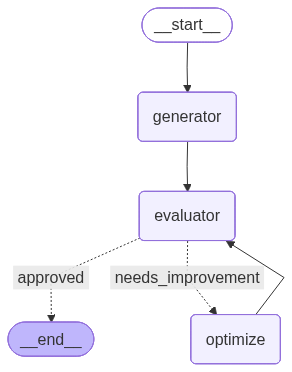

In [94]:
workflow

In [99]:
initial_state={"topic":"Salmaan Khan","iteration":1,"max_iteration":8}
workflow.invoke(initial_state)

{'topic': 'Salmaan Khan',
 'tweet': '**Tweet**\n\nSalmaan Khan’s workout plan: 10\u202fkm of “machis” (match‑stick runs) at dawn, 10\u202fkm of over‑the‑top dialogues at dusk. No wonder he’s still chasing the 1990s action‑hero vibe. #SalmaanKhan #FitnessGoals #Bollywood  \n\n**Why it works**  \n- **Observational humor:** riffs on the typical Bollywood “hero‑fitness” montage.  \n- **Irony:** “machis” (tiny matches) vs. real cardio, highlighting the gap between hype and effort.  \n- **Cultural reference:** nods to 90s action stars and their melodramatic one‑liners.  \n- **Meme logic:** a concise, punchy comparison that’s instantly visual and shareable.',
 'eval': 'approved',
 'feedback': "While this tweet hits multiple marks with its observational humor, irony, and cultural reference, the punchline's reliance on a predictable Bollywood 'hero-fitness' trope and the somewhat generic meme logic prevent it from truly standing out. It's a clever, shareable comparison, but it feels overly fami